In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt


def one_hot_encode(y, num_classes=10):
    y = y.reshape(-1).astype(int)
    out = np.zeros((y.shape[0], num_classes), dtype=np.float32)
    out[np.arange(y.shape[0]), y] = 1.0
    return out


def softmax(logits):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_vals = np.exp(shifted)
    return exp_vals / np.sum(exp_vals, axis=1, keepdims=True)

load the data

In [2]:
def load_data(filepath):
    with h5py.File(filepath, "r") as f:
        X = np.array(f["xdata"], dtype=np.float32) / 255.0
        y = np.array(f["ydata"])
    if X.ndim > 2:
        X = X.reshape(X.shape[0], -1)
    if y.ndim == 2 and y.shape[1] == 10:
        y_int = np.argmax(y, axis=1).astype(int)
    else:
        y_int = y.reshape(-1).astype(int)
    return X.astype(np.float32), y_int


X_all, y_all_int = load_data("mnist_traindata.hdf5")
y_all_oh = one_hot_encode(y_all_int)

X_tr = X_all[:50000]
y_tr_int = y_all_int[:50000]
y_tr_oh = y_all_oh[:50000]

X_val = X_all[50000:]
y_val_int = y_all_int[50000:]
y_val_oh = y_all_oh[50000:]

Activation functions and their derivatives

In [3]:
def activation_fn(z, activation):
    if activation == "tanh":
        return np.tanh(z)
    return np.maximum(0.0, z)


def activation_deriv(a, activation):
    if activation == "tanh":
        return 1.0 - a * a
    return (a > 0).astype(a.dtype)

Xavier initialization for all layers

In [4]:
def init_weights(layer_sizes):
    W = []
    b = []
    for i in range(len(layer_sizes) - 1):
        size1 = layer_sizes[i]
        size2 = layer_sizes[i + 1]
        std = np.sqrt(2.0 / (size1 + size2))
        W.append((np.random.randn(size1, size2) * std).astype(np.float32))
        b.append(np.zeros((1, size2), dtype=np.float32))
    return W, b

forward pass, backprop and updates

In [5]:
def forward(X, W, b, activation):
    a = X
    activations = [X]
    for i in range(len(W) - 1):
        z = a @ W[i] + b[i]
        a = activation_fn(z, activation)
        activations.append(a)
    logits = a @ W[-1] + b[-1]
    activations.append(logits)
    return logits, activations


def backward(y_onehot, logits, activations, W, activation):
    batch_size = y_onehot.shape[0]
    probs = softmax(logits)
    delta = probs - y_onehot

    dW = [None] * len(W)
    db = [None] * len(W)

    dW[-1] = (activations[-2].T @ delta) / batch_size
    db[-1] = np.sum(delta, axis=0, keepdims=True) / batch_size

    for layer in range(len(W) - 2, -1, -1):
        a_hidden = activations[layer + 1]
        delta = (delta @ W[layer + 1].T) * activation_deriv(a_hidden, activation)
        dW[layer] = (activations[layer].T @ delta) / batch_size
        db[layer] = np.sum(delta, axis=0, keepdims=True) / batch_size

    return dW, db


def update(W, b, dW, db, lr):
    for i in range(len(W)):
        W[i] -= lr * dW[i]
        b[i] -= lr * db[i]

train and evals

In [6]:
def evaluate(X, y_int, y_onehot, W, b, activation):
    logits, xyz = forward(X, W, b, activation)
    preds = np.argmax(logits, axis=1)
    return np.mean(preds == y_int)


def train(X_tr, y_tr_int, y_tr_oh, X_val, y_val_int, y_val_oh, activation, init_lr, epochs, batch_size, hidden_sizes):

    layers = [784] + hidden_sizes + [10]
    W, b = init_weights(layers)
    n = X_tr.shape[0]
    lr = init_lr

    tr_hist = []
    val_hist = []

    for ep in range(1, epochs + 1):
        if ep == 21 or ep == 41:
            lr = lr / 2.0

        perm = np.random.permutation(n)
        X_shuf = X_tr[perm]
        y_shuf = y_tr_oh[perm]

        for start in range(0, n, batch_size):
            xb = X_shuf[start:start + batch_size]
            yb = y_shuf[start:start + batch_size]
            logits, acts = forward(xb, W, b, activation)
            dW, db_grad = backward(yb, logits, acts, W, activation)
            update(W, b, dW, db_grad, lr)

        tr_acc = evaluate(X_tr, y_tr_int, y_tr_oh, W, b, activation)
        val_acc = evaluate(X_val, y_val_int, y_val_oh, W, b, activation)
        tr_hist.append(tr_acc)
        val_hist.append(val_acc)

    print(activation, "| lr =", init_lr, "| Train Acc", tr_acc * 100, "| Val Acc", val_acc * 100)
    return W, b, tr_hist, val_hist


def train_full(X, y_int, y_oh, activation, init_lr, epochs, batch_size, hidden_sizes):

    layers = [784] + hidden_sizes + [10]
    W, b = init_weights(layers)
    n = X.shape[0]
    lr = init_lr

    for ep in range(1, epochs + 1):
        if ep == 21 or ep == 41:
            lr = lr / 2.0

        perm = np.random.permutation(n)
        X_shuf = X[perm]
        y_shuf = y_oh[perm]

        for start in range(0, n, batch_size):
            xb = X_shuf[start:start + batch_size]
            yb = y_shuf[start:start + batch_size]
            logits, acts = forward(xb, W, b, activation)
            dW, db_grad = backward(yb, logits, acts, W, activation)
            update(W, b, dW, db_grad, lr)

    tr_acc = evaluate(X, y_int, y_oh, W, b, activation)
    print("Final train acc:", tr_acc * 100)
    return W, b


def plot_history(tr_hist, val_hist, activation, lr):
    eps = np.arange(1, len(tr_hist) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(eps, np.array(tr_hist) * 100, label="Training Accuracy")
    plt.plot(eps, np.array(val_hist) * 100, label="Validation Accuracy")
    plt.axvline(x=20, linestyle="--", color="gray", label="LR decay")
    plt.axvline(x=40, linestyle="--", color="gray")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Activation = %s, Initial LR = %s" % (activation, lr))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

running the code

tanh | lr = 0.1 | Train Acc 67.52 | Val Acc 69.64


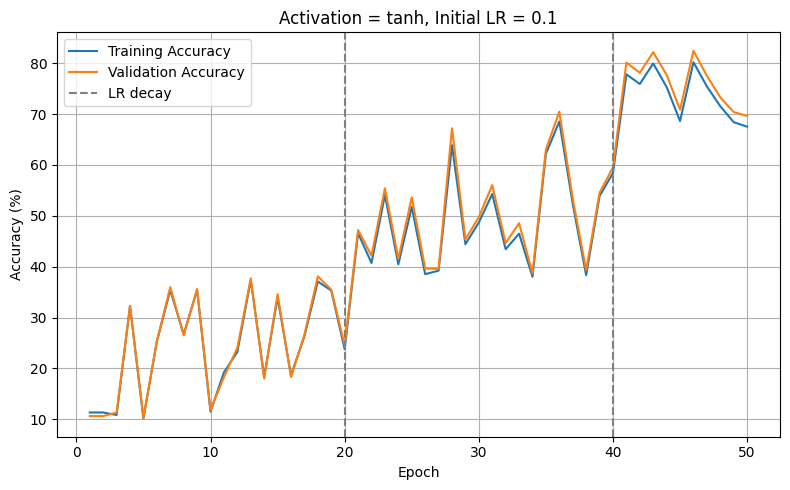

tanh | lr = 0.05 | Train Acc 43.324 | Val Acc 43.25


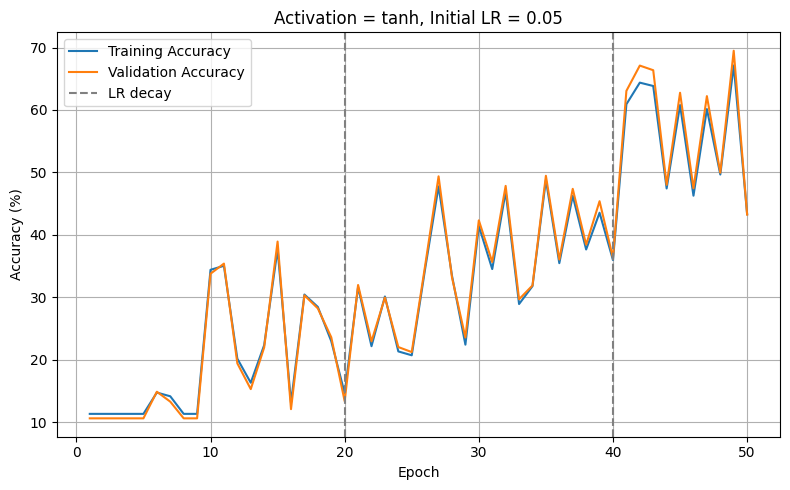

tanh | lr = 0.01 | Train Acc 11.356 | Val Acc 10.639999999999999


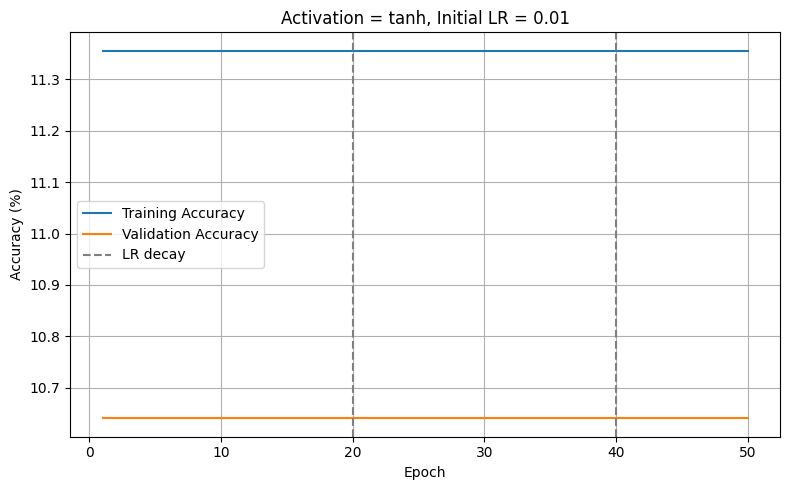

relu | lr = 0.1 | Train Acc 54.006 | Val Acc 55.589999999999996


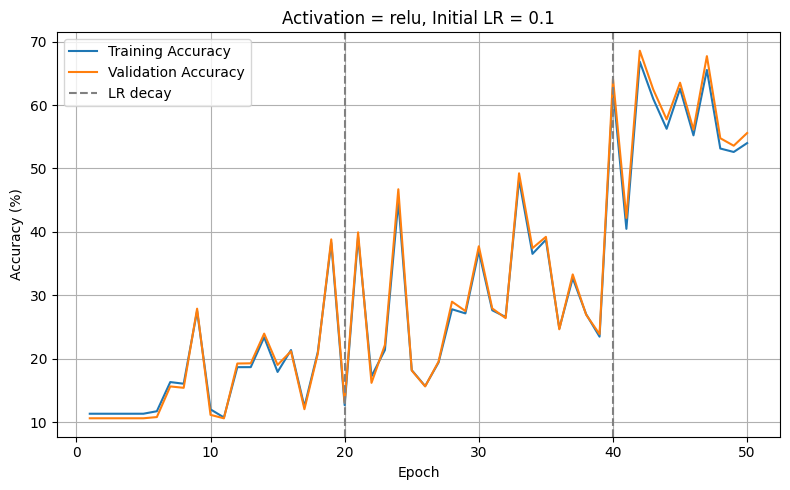

relu | lr = 0.05 | Train Acc 45.757999999999996 | Val Acc 47.099999999999994


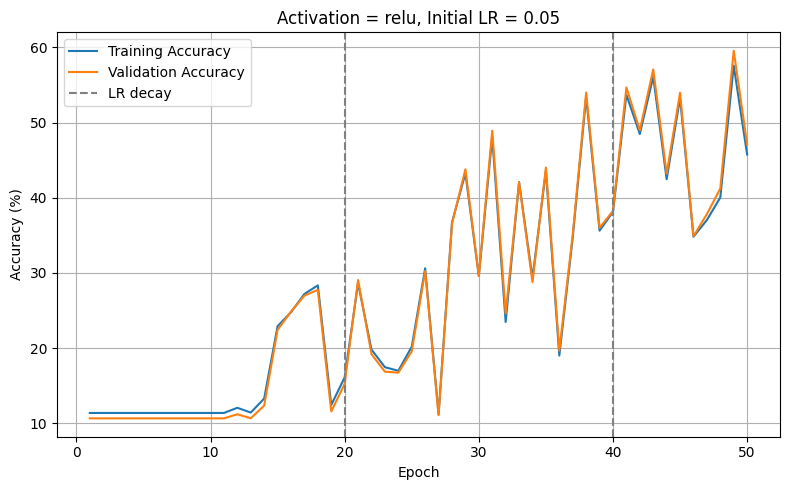

relu | lr = 0.01 | Train Acc 11.356 | Val Acc 10.639999999999999


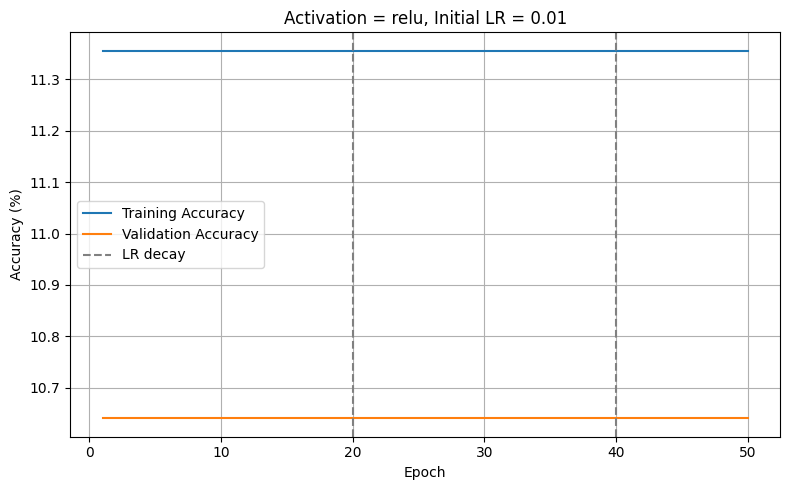

Best activation: tanh
Best learning rate: 0.1
Best val accuracy: 82.45


In [7]:
hidden_sizes = [512, 256, 128]
batch_size = 200
learning_rates = [0.1, 0.05, 0.01]
activations = ["tanh", "relu"]
epochs = 50

best_act = None
best_lr = None
best_val_acc = -1.0
all_results = {}

for act_name in activations:
    for lr in learning_rates:
        W, b, tr_hist, val_hist = train(
            X_tr, y_tr_int, y_tr_oh,
            X_val, y_val_int, y_val_oh,
            act_name, lr, epochs, batch_size, hidden_sizes
        )

        all_results[(act_name, lr)] = (tr_hist, val_hist)
        plot_history(tr_hist, val_hist, act_name, lr)

        peak = max(val_hist)
        if peak > best_val_acc:
            best_val_acc = peak
            best_act = act_name
            best_lr = lr

print("Best activation:", best_act)
print("Best learning rate:", best_lr)
print("Best val accuracy:", best_val_acc * 100)

In [8]:
final_W, final_b = train_full(
    X_all, y_all_int, y_all_oh,
    best_act, best_lr, epochs, batch_size, hidden_sizes
)

Final train acc: 76.08333333333334


In [9]:
X_test, y_test_int = load_data("mnist_testdata.hdf5")
y_test_oh = one_hot_encode(y_test_int)

test_acc = evaluate(X_test, y_test_int, y_test_oh, final_W, final_b, best_act)

print("Network:", [784] + hidden_sizes + [10])
print("Batch size:", batch_size)
print("Learning rates:", learning_rates)
print("Initialization: Xavier")
print("Best activation:", best_act)
print("Best LR:", best_lr)
print("Test accuracy:", test_acc * 100)

Network: [784, 512, 256, 128, 10]
Batch size: 200
Learning rates: [0.1, 0.05, 0.01]
Initialization: Xavier
Best activation: tanh
Best LR: 0.1
Test accuracy: 76.3
